# Physics-Informed Neural Networks

## Allan Peter Engsig-Karup (apek@dtu.dk)
## May 7th, 2024

In [1]:
import notebook as nb
print(nb.__version__)

7.5.6


In [2]:
import types
def imports():
    for name, val in globals().items():
        if isinstance(val, types.ModuleType):
            yield val.__name__ 
list(imports())

['builtins', 'builtins', 'notebook', 'types']

We consider in the following the use of Physics-Informed Neural Networks(PINNs) for the construction of a surrogate model for the solution to the linear advection equation in one space dimension.
$u_{t}+cu_{x}=0 \qquad  t ∈ \mathbb{R^+}, x ∈ \mathbb{R}$ 
This problem have analytical solutions in the form $u(x,t)=f(x-ct)$, and an initial condition of the form $u(x,0)=f(x)=\sin(\pi x)$ is assumed. For $c>0$, a boundary condition is imposed on the left boundary because the information is travelling from left to right in this case
$u(0,t)=f(-ct)=\sin(-\pi ct)$

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# High precision
torch.set_default_dtype(torch.float64)

# Define device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA on GPU")
# Check for MPS availability next if CUDA is not available (for macOS with Apple Silicon)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS on Apple Silicon GPU")
    torch.set_default_dtype(torch.float32) # mps does not allow for float64
# Default to CPU if neither CUDA nor MPS is available
else:
    device = torch.device("cpu")
    print("Using CPU")

def u_exact(x, t, eps=0.1):

    alphas = torch.tensor([1.0, 4.0, 16.0], device=device, dtype=torch.get_default_dtype())
    u = torch.zeros_like(x)

    for alpha in alphas:
        u = u + torch.exp(-eps * alpha**2 * t) * torch.cos(alpha * x)

    return u

def gL(t):
    x = torch.full_like(t, -1.0)
    return u_exact(x, t)

def gR(t):
    x = torch.full_like(t, 1.0)
    return u_exact(x, t)

def eta(x, eps=0.1):
    t = torch.zeros_like(x)
    return u_exact(x, t, eps)

# Define the neural network model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Sigmoid(),
            nn.Linear(40, 40),
            nn.Sigmoid(),
            nn.Linear(40, 40),
            nn.Sigmoid(),
            nn.Linear(40, 40),
            nn.Sigmoid(),
            nn.Linear(40, 1)
        )

    def forward(self, x, t):
        xt = torch.cat((x, t), dim=1)
        u = self.net(xt)
        return u

# Helper functions to calculate derivatives
def grad(outputs, inputs):
    return torch.autograd.grad(outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True, retain_graph=True)[0]

# Physics-informed loss
def loss_fn(model, x, t, eps, gL, gR, eta):
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, t)

    u_t = grad(u, t)
    u_xx = grad(grad(u, x), x)

    # PDE loss
    f = u_t - eps * u_xx  # Ensure 'c' is defined or passed to the function

    # Boundary conditions (ensure these are correct for your problem)
    left_boundary_condition = model(-torch.ones_like(x), t) - gL(t)
    right_boundary_condition = model(torch.ones_like(x), t) - gR(t)
    initial_condition = model(x, torch.zeros_like(t)) - eta(x)

    # Compute MSE for PDE, boundary, and initial conditions
    loss_pde = torch.mean(f**2)
    loss_boundary = torch.mean(left_boundary_condition**2 + right_boundary_condition**2)
    loss_initial = torch.mean(initial_condition**2)

    return loss_pde + 10.0*loss_boundary + 10.0*loss_initial
    
# Training
def train(model, epochs, optimizer, optimizer2, x, t,eps):
    model.train()
    for epoch in range(3000):
        optimizer.zero_grad()
        l = loss_fn(model, x, t, eps, gL, gR, eta)
        l.backward()
        optimizer.step()
        if epoch % 150 == 0:
            print(f'Epoch {epoch}: Loss = {l.item()}')
    for epoch in range(3000, epochs):
        def closure():
            optimizer2.zero_grad()
            l = loss_fn(model, x, t, eps, gL, gR, eta)
            l.backward()
            return l

        l = optimizer2.step(closure)
        l = loss_fn(model, x, t, eps, gL, gR, eta)
        l.backward()
        optimizer2.step()
        if epoch % 150 == 0:
            print(f'Epoch {epoch}: Loss = {l.item()}')


# Grid points
xmin, xmax, nx = -1, 1, 100
tmin, tmax, nt = 0, 1, 100
x = torch.linspace(xmin, xmax, nx, device=device).unsqueeze(1)
t = torch.linspace(tmin, tmax, nt, device=device).unsqueeze(1)
x_mesh, t_mesh = torch.meshgrid(x.flatten(), t.flatten())
x_mesh, t_mesh = x_mesh.flatten().unsqueeze(1), t_mesh.flatten().unsqueeze(1)

# Constants
eps = 0.1

# Initialize model, optimizer
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
optimizer2 = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=3000, max_eval=500, history_size=50)

# Train the model
train(model, 15000, optimizer, optimizer2, x_mesh, t_mesh, eps)
# torch.save(model.state_dict(), "pinn_model_ex2_sig_256.pth")
# print("Saved model to pinn_model_ex2_sig_256.pth")


Using MPS on Apple Silicon GPU
Epoch 0: Loss = 16.087194442749023
Epoch 150: Loss = 5.426513671875
Epoch 300: Loss = 4.783241271972656
Epoch 450: Loss = 3.9755523204803467
Epoch 600: Loss = 2.254330635070801
Epoch 750: Loss = 1.684336543083191
Epoch 900: Loss = 0.8629619479179382
Epoch 1050: Loss = 0.5479369163513184
Epoch 1200: Loss = 0.4411977529525757
Epoch 1350: Loss = 0.34147223830223083
Epoch 1500: Loss = 0.5172203779220581
Epoch 1650: Loss = 0.23792582750320435
Epoch 1800: Loss = 0.2024746537208557
Epoch 1950: Loss = 0.18739740550518036
Epoch 2100: Loss = 0.13701823353767395
Epoch 2250: Loss = 0.12720251083374023
Epoch 2400: Loss = 0.0985802635550499
Epoch 2550: Loss = 0.09168675541877747
Epoch 2700: Loss = 0.07528854161500931
Epoch 2850: Loss = 0.07142766565084457


TypeError: LBFGS.step() missing 1 required positional argument: 'closure'

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Assuming 'model' and 'device' are already defined and the model is trained.
# Load the trained model
model.load_state_dict(torch.load("pinn_model_ex2_sig_256.pth", map_location=device))

# Generate predictions from the trained model
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    u_pred = model(x_mesh, t_mesh).cpu().numpy()


# Exact solution (update this according to your problem's exact solution)
u_anal = u_exact(x_mesh, t_mesh, eps=eps).detach().cpu().numpy()
                 


In [5]:
# Compute L2 errors
l2_err = np.sum((u_anal - u_pred)**2)
l2_err_t0 = np.sum((u_anal[0, :] - u_pred[0, :])**2)
l2_err_tmax = np.sum((u_anal[-1, :] - u_pred[-1, :])**2)

# Output error information
print(f'L2 err, all timesteps: {l2_err}')
print(f'Avg-L2 err, all timesteps: {l2_err/u_pred.size}')
print(f'L2 err, t=0: {l2_err_t0}')
print(f'L2 err, t={tmax}: {l2_err_tmax}')

# # Write to file
# with open('pinn_errors_ex2.txt', 'w') as f:
#     f.write(f'\n=== Tanh activation function ===\n')
#     f.write(f'L2 err, all timesteps: {l2_err}\n')
#     f.write(f'Avg-L2 err, all timesteps: {l2_err/u_pred.size}\n')
#     f.write(f'L2 err, t=0: {l2_err_t0}\n')
#     f.write(f'L2 err, t={tmax}: {l2_err_tmax}\n')


L2 err, all timesteps: 1.0272719860076904
Avg-L2 err, all timesteps: 0.0001027272010105662
L2 err, t=0: 0.001736415782943368
L2 err, t=1: 0.00014348178228829056


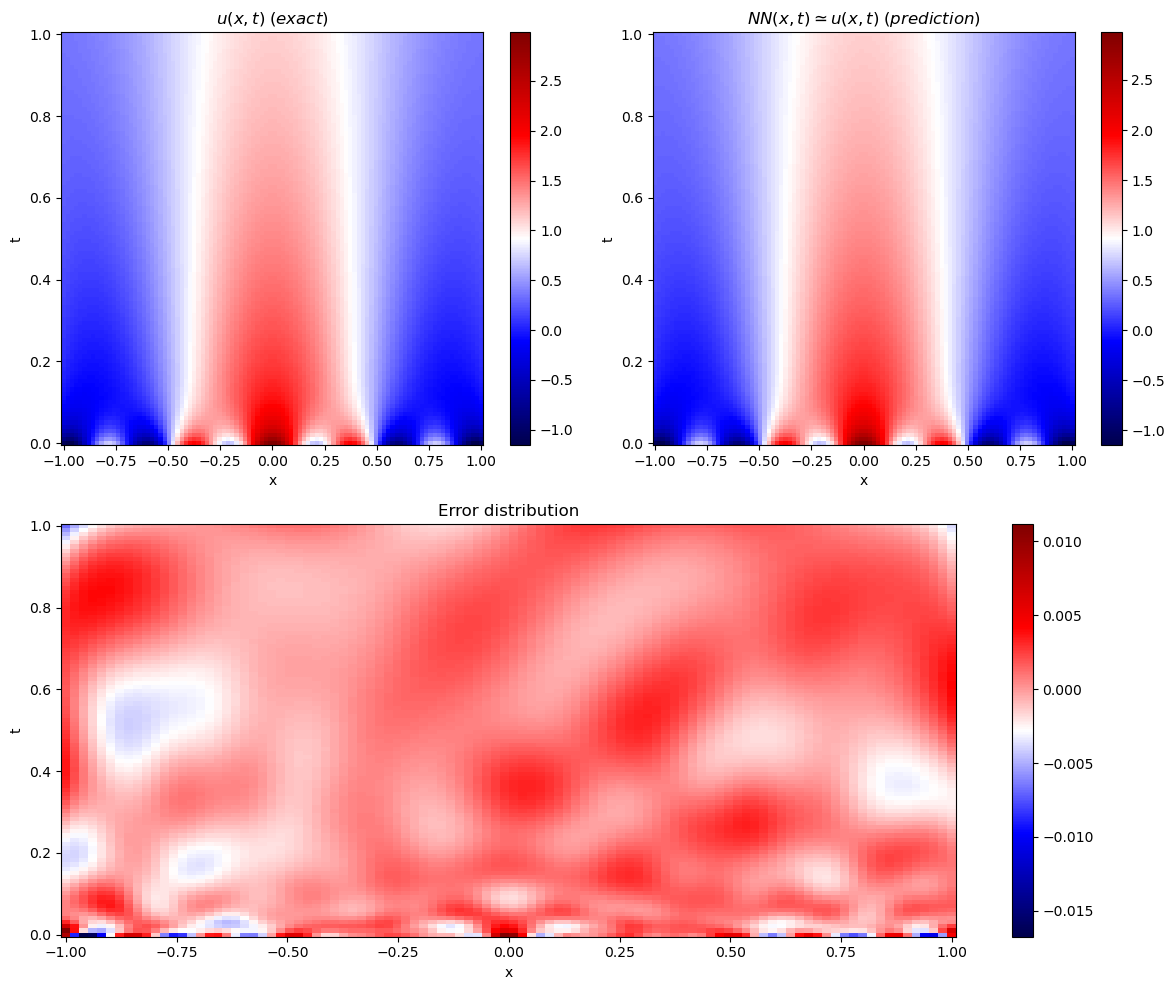

In [15]:
# Assuming your x_mesh and t_mesh are defined correctly in the tensor form.
x = torch.linspace(xmin, xmax, nx, device=device).cpu().numpy()
t = torch.linspace(tmin, tmax, nt, device=device).cpu().numpy()

# Since these are grid centers, calculate the step size and expand the grid to cover edges.
x_step = (x[1] - x[0])
t_step = (t[1] - t[0])

# Create new arrays that represent the edges, not the centers
x_edges = np.append(x, x[-1] + x_step) - x_step/2
t_edges = np.append(t, t[-1] + t_step) - t_step/2

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2)

ax = fig.add_subplot(gs[0, 0])
cc = ax.pcolormesh(x_edges, t_edges, u_anal.reshape((nx, nt)).T, cmap='seismic', shading='auto')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(r'$u(x,t) \; (exact)$')
fig.colorbar(cc, ax=ax)

ax = fig.add_subplot(gs[0, 1])
cc = ax.pcolormesh(x_edges, t_edges, u_pred.reshape((nx, nt)).T, cmap='seismic', shading='auto')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(r'$NN(x,t)\simeq u(x,t) \; (prediction)$')
fig.colorbar(cc, ax=ax)

ax = fig.add_subplot(gs[1, :])
cc = ax.pcolormesh(
    x_edges, t_edges,
    (u_anal.reshape((nx, nt)).T - u_pred.reshape((nx, nt)).T),
    cmap='seismic', shading='auto'
)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Error distribution')
fig.colorbar(cc, ax=ax)

plt.tight_layout()


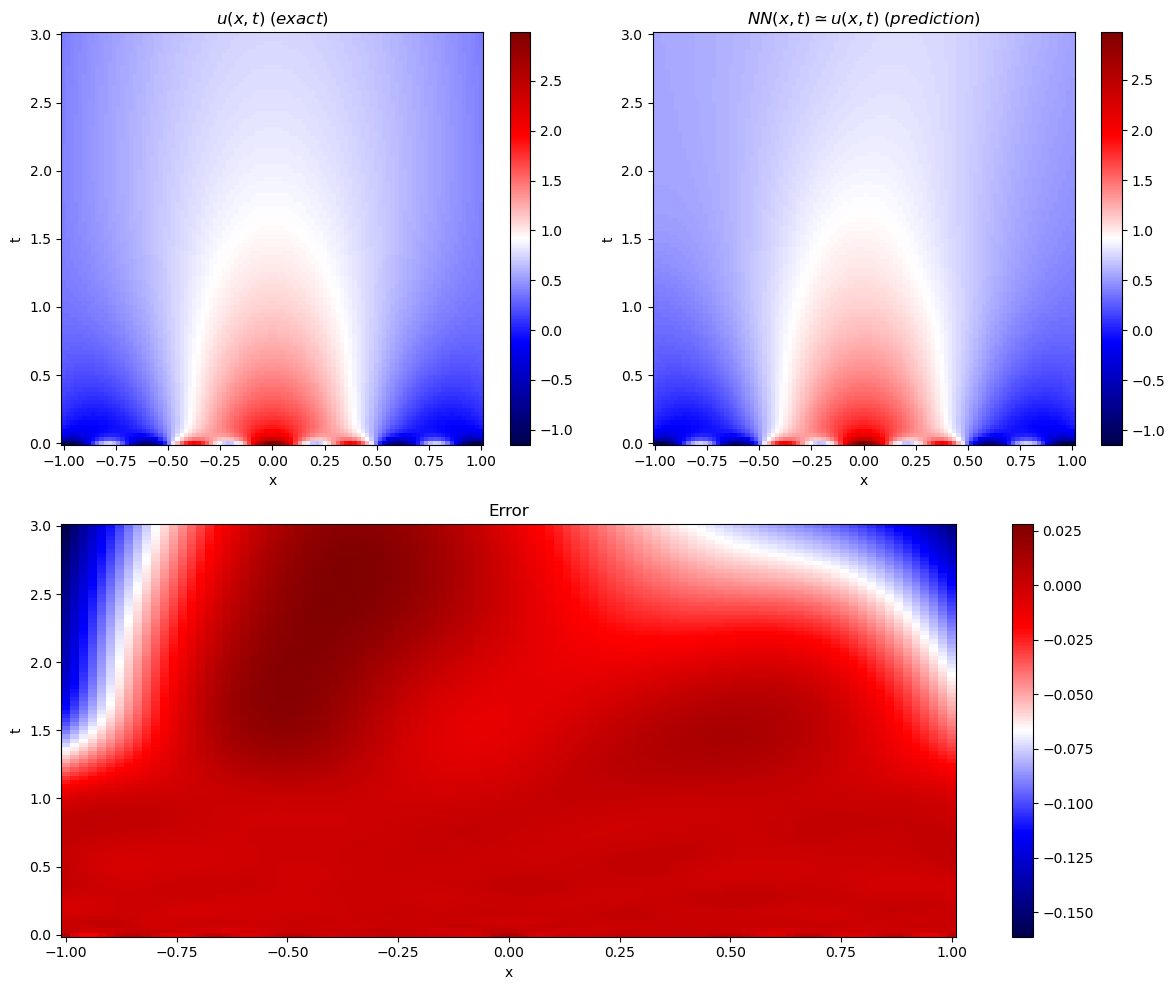

In [21]:
# Grid points
xmin, xmax, nx = -1, 1, 100
tmin, tmax, nt = 0, 3, 100
x = torch.linspace(xmin, xmax, nx, device=device).unsqueeze(1)
t = torch.linspace(tmin, tmax, nt, device=device).unsqueeze(1)
x_mesh, t_mesh = torch.meshgrid(x.flatten(), t.flatten())
x_mesh, t_mesh = x_mesh.flatten().unsqueeze(1), t_mesh.flatten().unsqueeze(1)

# Assuming 'model' and 'device' are already defined and the model is trained.
# Load the trained model
model.load_state_dict(torch.load("pinn_model_ex2_sig.pth", map_location=device))

# Generate predictions from the trained model
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    u_pred = model(x_mesh, t_mesh).cpu().numpy()


# Assuming your x_mesh and t_mesh are defined correctly in the tensor form.
x = torch.linspace(xmin, xmax, nx, device=device).cpu().numpy()
t = torch.linspace(tmin, tmax, nt, device=device).cpu().numpy()

# Since these are grid centers, calculate the step size and expand the grid to cover edges.
x_step = (x[1] - x[0])
t_step = (t[1] - t[0])

# Create new arrays that represent the edges, not the centers
x_edges = np.append(x, x[-1] + x_step) - x_step/2
t_edges = np.append(t, t[-1] + t_step) - t_step/2


# Exact solution (update this according to your problem's exact solution)
u_anal = u_exact(x_mesh, t_mesh, eps=eps).detach().cpu().numpy()

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2)

ax = fig.add_subplot(gs[0, 0])
cc = ax.pcolormesh(x_edges, t_edges, u_anal.reshape((nt, nx)).T, cmap='seismic', shading='auto')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(r'$u(x,t) \; (exact)$')
fig.colorbar(cc, ax=ax)

ax = fig.add_subplot(gs[0, 1])
cc = ax.pcolormesh(x_edges, t_edges, u_pred.reshape((nt, nx)).T, cmap='seismic', shading='auto')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(r'$NN(x,t)\simeq u(x,t) \; (prediction)$')
fig.colorbar(cc, ax=ax)

ax = fig.add_subplot(gs[1, :])
cc = ax.pcolormesh(
    x_edges, t_edges,
    u_anal.reshape((nt, nx)).T - u_pred.reshape((nt, nx)).T,
    cmap='seismic', shading='auto'
)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Error')
fig.colorbar(cc, ax=ax)

plt.tight_layout()
